<a href="https://colab.research.google.com/github/Kazuhiro-Matsui/salesforecast_supermarket/blob/main/demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 需要予測モデル-デモ- (概要)

とあるスーパーの商品販売量データ(https://www.kaggle.com/competitions/store-sales-time-series-forecasting)の内、2016-07-15～2017-07-31までの惣菜('PREPARED FOODS')の販売量データを基にlightGBMを用いて予測モデルを作成し、2017-08-01～2017-8-15の売り上げ量を予測。実測値と予測値の差から、このモデルがこのスーパーで惣菜の発注量を決める際に頼るに足る精度を持つかどうかを評価する。

### Google ColabをGoogle Drive接続し、Google Driveに保存したオープンデータにアクセスできるようにする。

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# フォルダパスはスクリーンショットから推測しています。適宜修正してください。
# !unzip "ZIPファイルのパス" -d "解凍先のパス"
!unzip -o -q "/content/drive/MyDrive/salesforecast_supermarket_demo/store-sales-time-series-forecasting.zip" -d "/content/dataset"

### 生データ(オープンデータそのもの)の内、DAIRY(乳製品), BREAD/BAKERY(パン類), PREPARED FOODS(惣菜), PRODUCE(青果)のデータの最初5行を可視化。
・onpromotion：特定の日付に店舗でプロモーションされていた製品ファミリー内のアイテムの総数

In [ ]:
import pandas as pd

# 1. データの読み込み
df = pd.read_csv('/content/dataset/train.csv')

# 2. 日付列を日付型に変換（フィルタリングしやすくするため）
df['date'] = pd.to_datetime(df['date'])

# 3. 条件設定
target_store = 3
start_date = '2016-07-15'
end_date = '2017-08-15'
target_families = ['DAIRY', 'BREAD/BAKERY', 'PREPARED FOODS', 'PRODUCE']

# 4. フィルタリング実行
filtered_df = df[
    (df['store_nbr'] == target_store) &
    (df['date'] >= start_date) &
    (df['date'] <= end_date) &
    (df['family'].isin(target_families))
].copy()

# 5. 結果の確認
print(f"データ件数: {len(filtered_df)} 件")
display(filtered_df.head(5))

# カテゴリごとの件数も確認しておくと安心です
print(filtered_df['family'].value_counts())

データ件数: 1584 件


,id,date,store_nbr,family,sales,onpromotion
2295947,2295947,2016-07-15,3,BREAD/BAKERY,1375.786,1
2295950,2295950,2016-07-15,3,DAIRY,2396.000,11
2295971,2295971,2016-07-15,3,PREPARED FOODS,390.693,1
2295972,2295972,2016-07-15,3,PRODUCE,7479.879,3
2297729,2297729,2016-07-16,3,BREAD/BAKERY,1633.194,1


family
BREAD/BAKERY      396
DAIRY             396
PREPARED FOODS    396
PRODUCE           396
Name: count, dtype: int64


### データを成形する
→・日付をインデックスに
　・特別なイベントがあった日かどうか(is_event)
　・土日祝日含めて、休日かどうか(is_workday)
  ・曜日:月曜日から順に0,1,...6

In [ ]:
import pandas as pd

# 1. ZIPから holidays_events.csv を解凍して読み込む
# （※上書き確認が出ないように -o オプションをつけています）

df_holidays = pd.read_csv('/content/dataset/holidays_events.csv')

# date列を日付型に変換
df_holidays['date'] = pd.to_datetime(df_holidays['date'])


# 2. 「is_event」列の追加（イベント日=1、それ以外=0）
# typeが 'Event' になっている日付のリストを取得
event_dates = df_holidays[df_holidays['type'] == 'Event']['date'].unique()

# filtered_dfの日付が、イベント日リストに含まれていれば True(1)、いなければ False(0)
filtered_df['is_event'] = filtered_df['date'].isin(event_dates).astype(int)


# 3. 「is_workday」列（出勤日・平日=1、土日祝=0）の追加
# ① まずベースとして、月〜金(dayofweekが0~4)を「1」、土日(5, 6)を「0」にします
filtered_df['is_workday'] = (~filtered_df['date'].dt.dayofweek.isin([5, 6])).astype(int)

# ② 祝日・休日（Holiday, Bridge 等）の日付リストを取得
# （※ transferred == False は「別の日に振り替えられていない、本当の休日」を意味します）
holiday_dates = df_holidays[
    (df_holidays['type'].isin(['Holiday', 'Transfer', 'Additional', 'Bridge'])) &
    (df_holidays['transferred'] == False)
]['date'].unique()

# ③ 振替出勤日（土日だけど出勤日扱いになる日 = 'Work Day'）の日付リストを取得
work_dates = df_holidays[df_holidays['type'] == 'Work Day']['date'].unique()

# ④ 祝日リストに含まれる日は、is_workday を「0（休日）」に上書き
filtered_df.loc[filtered_df['date'].isin(holiday_dates), 'is_workday'] = 0

# ⑤ 振替出勤日リストに含まれる日は、is_workday を「1（出勤日）」に上書き
filtered_df.loc[filtered_df['date'].isin(work_dates), 'is_workday'] = 1


# 4. 'date' 列をインデックスに設定する
filtered_df = filtered_df.set_index('date')
# 曜日を数値で追加（0=月, 6=日）
filtered_df['day_of_week'] = filtered_df.index.dayofweek

# 結果の確認（最初の10行を表示）
display(filtered_df.head(10))

# 今回の対象期間内に Event が何日あったか、休日は何日あったかの集計も表示
print("\n--- フラグの集計結果 ---")
print(f"イベント日 (is_event=1) のデータ数: {filtered_df['is_event'].sum()}件")
print(f"休日・土日 (is_workday=0) のデータ数: {(filtered_df['is_workday'] == 0).sum()}件")
print(f"出勤日・平日 (is_workday=1) のデータ数: {filtered_df['is_workday'].sum()}件")

,id,store_nbr,family,sales,onpromotion,is_event,is_workday,day_of_week
date,,,,,,,,
2016-07-15,2295947,3,BREAD/BAKERY,1375.786,1,0,1,4
2016-07-15,2295950,3,DAIRY,2396.000,11,0,1,4
2016-07-15,2295971,3,PREPARED FOODS,390.693,1,0,1,4
2016-07-15,2295972,3,PRODUCE,7479.879,3,0,1,4
2016-07-16,2297729,3,BREAD/BAKERY,1633.194,1,0,0,5
2016-07-16,2297732,3,DAIRY,2762.000,11,0,0,5
2016-07-16,2297753,3,PREPARED FOODS,384.655,0,0,0,5
2016-07-16,2297754,3,PRODUCE,8768.461,3,0,0,5
2016-07-17,2299511,3,BREAD/BAKERY,1642.767,1,0,0,6



--- フラグの集計結果 ---
イベント日 (is_event=1) のデータ数: 12件
休日・土日 (is_workday=0) のデータ数: 588件
出勤日・平日 (is_workday=1) のデータ数: 996件


### 景気指標の特徴量追加
景気指標としてオープンデータから石油価格の時系列データをマージする。

In [ ]:
# 1. ZIPから oil.csv を解凍して読み込む

df_oil = pd.read_csv('/content/dataset/oil.csv')

# 2. date列を日付型に変換し、インデックスに設定
df_oil['date'] = pd.to_datetime(df_oil['date'])
df_oil = df_oil.set_index('date')

# 列名が 'dcoilwtico' で分かりにくいため、'oil_price' に変更
df_oil = df_oil.rename(columns={'dcoilwtico': 'oil_price'})

# 3. filtered_df に原油価格を結合（joinを使います）
# ※ filtered_df も df_oil もインデックスが 'date' なので綺麗に結合できます
filtered_df = filtered_df.join(df_oil, how='left')

# 4. 欠損値（NaN）の補完処理（非常に重要！）
# ffill() : forward fill（前の日のデータで埋める）
# bfill() : backward fill（万が一、データの一番最初が欠損していた場合のために後ろから埋める）
filtered_df['oil_price'] = filtered_df['oil_price'].ffill().bfill()

# 5. 結果の確認
# 土日（is_workdayが0の日）にも、直前の平日の価格がちゃんと入っているか確認できます
display(filtered_df.head(10))

# 欠損値（空のデータ）がゼロになっているか確認
print("\n--- 原油価格データの欠損値チェック ---")
print(f"oil_price列の空データ数: {filtered_df['oil_price'].isnull().sum()}件")

,id,store_nbr,family,sales,onpromotion,is_event,is_workday,day_of_week,oil_price
date,,,,,,,,,
2016-07-15,2295947,3,BREAD/BAKERY,1375.786,1,0,1,4,45.93
2016-07-15,2295950,3,DAIRY,2396.000,11,0,1,4,45.93
2016-07-15,2295971,3,PREPARED FOODS,390.693,1,0,1,4,45.93
2016-07-15,2295972,3,PRODUCE,7479.879,3,0,1,4,45.93
2016-07-16,2297729,3,BREAD/BAKERY,1633.194,1,0,0,5,45.93
2016-07-16,2297732,3,DAIRY,2762.000,11,0,0,5,45.93
2016-07-16,2297753,3,PREPARED FOODS,384.655,0,0,0,5,45.93
2016-07-16,2297754,3,PRODUCE,8768.461,3,0,0,5,45.93
2016-07-17,2299511,3,BREAD/BAKERY,1642.767,1,0,0,6,45.93



--- 原油価格データの欠損値チェック ---
oil_price列の空データ数: 0件


各商品カテゴリ(DAIRY, BREAD/BAKERY, PREPARED FOOD, PRODUCE)の販売量の時系列推移可視化(→傾向を定性的にみるためで特に意味ない）

array([[<Axes: xlabel='date'>, <Axes: xlabel='date'>],
       [<Axes: xlabel='date'>, <Axes: xlabel='date'>]], dtype=object)

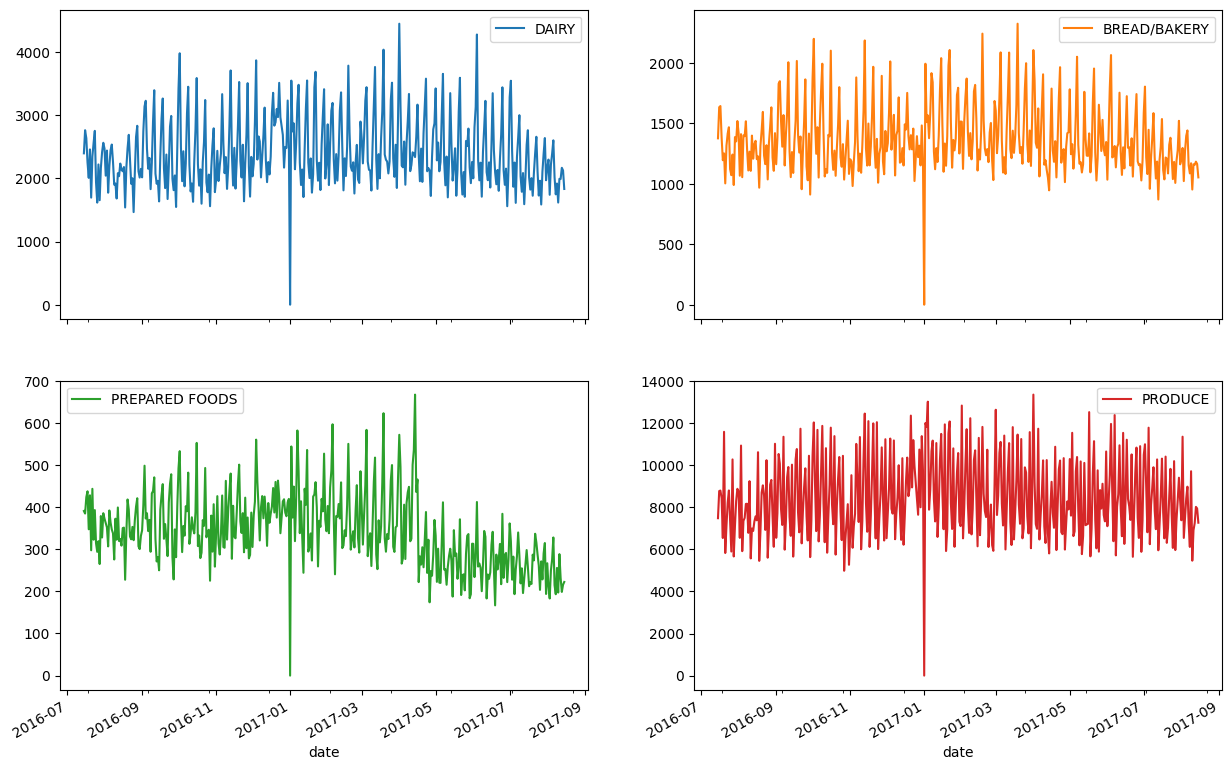

In [ ]:
pd.DataFrame({
    'DAIRY': filtered_df['sales'] [filtered_df['family'] == 'DAIRY'],
    'BREAD/BAKERY': filtered_df['sales'][filtered_df['family'] == 'BREAD/BAKERY'],
    'PREPARED FOODS': filtered_df['sales'][filtered_df['family'] == 'PREPARED FOODS'],
    'PRODUCE': filtered_df['sales'][filtered_df['family'] == 'PRODUCE'],
}).plot(subplots=True,      # 列ごとに別々のグラフにする
    layout=(2, 2),      # 2行 × 2列 のレイアウトで配置する
    figsize=(15, 10))

In [ ]:

filtered_df = filtered_df.drop(columns=filtered_df.columns[0:2])
filtered_df.head(10)

,family,sales,onpromotion,is_event,is_workday,day_of_week,oil_price
date,,,,,,,
2016-07-15,BREAD/BAKERY,1375.786,1,0,1,4,45.93
2016-07-15,DAIRY,2396.000,11,0,1,4,45.93
2016-07-15,PREPARED FOODS,390.693,1,0,1,4,45.93
2016-07-15,PRODUCE,7479.879,3,0,1,4,45.93
2016-07-16,BREAD/BAKERY,1633.194,1,0,0,5,45.93
2016-07-16,DAIRY,2762.000,11,0,0,5,45.93
2016-07-16,PREPARED FOODS,384.655,0,0,0,5,45.93
2016-07-16,PRODUCE,8768.461,3,0,0,5,45.93
2016-07-17,BREAD/BAKERY,1642.767,1,0,0,6,45.93


### 予測対象を惣菜に絞り、惣菜の時系列データを抽出

In [ ]:
df_pfood = filtered_df[filtered_df['family'] == 'PREPARED FOODS']
df_pfood = df_pfood.drop(columns=df_pfood.columns[0])
df_pfood.head(10)

,sales,onpromotion,is_event,is_workday,day_of_week,oil_price
date,,,,,,
2016-07-15,390.693,1,0,1,4,45.93
2016-07-16,384.655,0,0,0,5,45.93
2016-07-17,423.589,0,0,0,6,45.93
2016-07-18,437.400,0,0,1,0,45.23
2016-07-19,347.349,0,0,1,1,44.64
2016-07-20,427.958,1,0,1,2,44.96
2016-07-21,297.466,0,0,1,3,43.96
2016-07-22,443.345,1,0,1,4,43.41
2016-07-23,322.592,0,0,0,5,43.41


### onpromotionつまり惣菜のうち、プロモーションされたアイテム数の時系列推移

,onpromotion
count,396.000000
mean,0.691919
std,0.925605
min,0.000000
25%,0.000000
50%,0.000000
75%,1.000000
max,4.000000


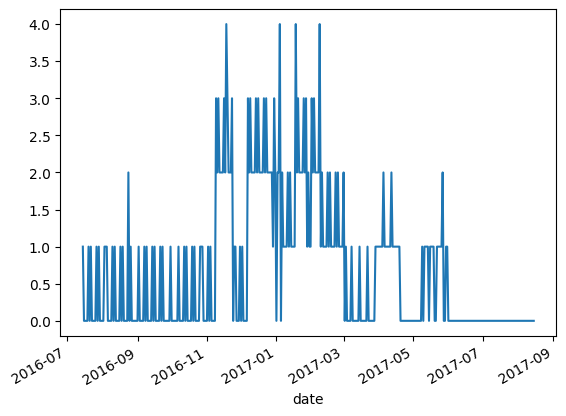

In [ ]:
pd.Series(df_pfood['onpromotion']).plot()
pd.Series(df_pfood['onpromotion']).describe()

### イベント日(is_event==0)、休日(is_workday==0)の惣菜売り上げ量推移
この結果から、イベント日の売り上げ量が休日の売り上げ量と著しく解離していないことが分かったので、以降でイベント日つまりis_event==0の日(時点）をis_workday==0とし、is_event列を削除。

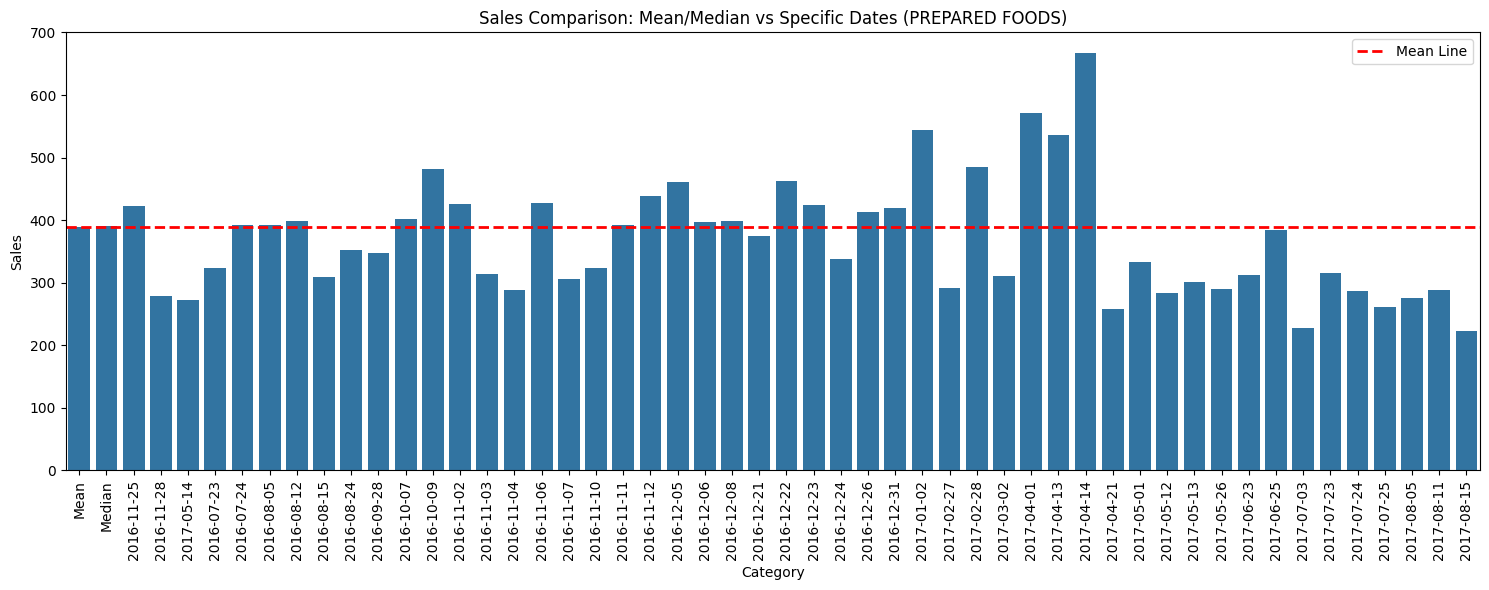

,Sales
count,52.000000
mean,369.252111
std,91.122069
min,222.294000
25%,298.821750
50%,364.000000
75%,420.179015
max,666.917970


In [ ]:


import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. イベント日と祝日を1つのリストにまとめる
# (.unique() の結果を list() で安全なリストに変換してから結合します)
a = list(event_dates) + list(holiday_dates)

# （補足）もし重複する日付を除外したい場合は、以下を実行します


# =========================================================
# ★注意: 分析したい売上列の名前を設定してください。
# 以前のやり取りでデータを横持ちに展開している場合は 'PREPARED FOODS' 等になります。
# 展開前のデータであれば 'sales' にしてください。
target_col = 'PREPARED FOODS'  # または 'sales'
# =========================================================

# 2. 休日・イベント全体での平均値と中央値を計算
data_dict = {
    'Mean': df_pfood['sales'][df_pfood['is_workday'] == 0].mean(),
    'Median': df_pfood['sales'][df_pfood['is_workday'] == 0].median()
}

# 3. 指定した各日付の売上を抽出
for date in a:
    # その日付が df_pfood のインデックスに存在するかチェック
    if date in df_pfood.index:
        # インデックスを指定して値を取得 (.loc を使います)
        val = df_pfood.loc[date, 'sales']



        # グラフの横軸を綺麗にするため、日付を文字列（YYYY-MM-DD形式）に変換
        date_str = pd.to_datetime(date).strftime('%Y-%m-%d')

        # 辞書に追加
        data_dict[date_str] = val

# 4. グラフ描画用のデータフレームを作成
df_f = pd.DataFrame({
    'Category': list(data_dict.keys()),
    'Sales': list(data_dict.values())
})

# 5. グラフの描画
plt.figure(figsize=(15, 6)) # 日付が多いと思うので、グラフを横長(15)にします
sns.barplot(data=df_f, x='Category', y='Sales')
plt.axhline(
    y=data_dict['Mean'],      # 線の高さ（上で計算した平均値）
    color='red',       # 線の色（赤）
    linestyle='--',    # 線の種類（点線/破線）
    linewidth=2,       # 線の太さ
    label='Mean Line'  # 凡例用の名前
)
# 凡例を表示する
plt.legend()
# 横軸の文字が重ならないように90度回転させる
plt.xticks(rotation=90)
plt.title(f'Sales Comparison: Mean/Median vs Specific Dates ({target_col})')
plt.tight_layout() # 余白の自動調整
plt.show()
df_f.describe()

### 景気指標として追加した石油価格データの時系列推移

,oil_price
count,396.000000
mean,48.428434
std,3.476703
min,39.500000
25%,45.780000
50%,48.480000
75%,51.510000
max,54.480000


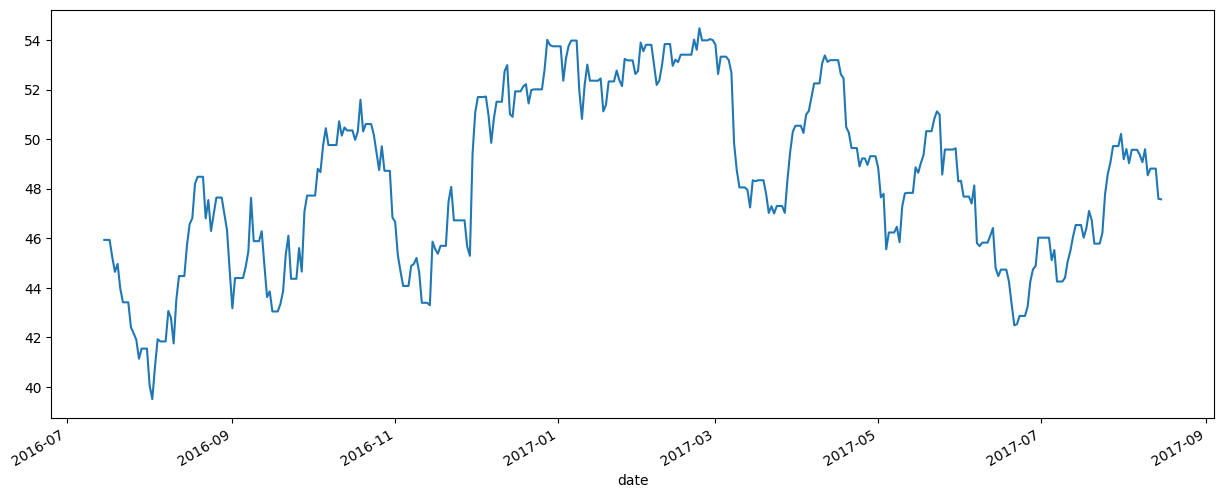

In [ ]:
df_pfood['oil_price'].plot(figsize=(15, 6))
df_pfood['oil_price'].describe()

### コレログラム作成
※コレログラム・・・時系列データの「周期性」や「過去の値との関係」を見るグラフ。n日前の値との相関係数を調べる。

売り上げ量予測のために、強い相関のある過去の時点の売り上げ量を説明変数としてモデルに学習させるため。

array([ 1.        ,  0.41321772,  0.12074304,  0.03289862,  0.11658375,
        0.1466047 ,  0.19771275,  0.48356332, -0.05145281, -0.09414264,
        0.0514774 ,  0.02486574,  0.00193416,  0.1323668 ,  0.26680041,
        0.02447685,  0.01499624, -0.07256814, -0.01609417, -0.00785605,
       -0.00867242,  0.1400572 , -0.08535874,  0.09450208, -0.00404612,
       -0.03538575,  0.00152995,  0.01169624,  0.13542376, -0.02241901,
       -0.00327277, -0.08179587])

<Figure size 1000x400 with 0 Axes>

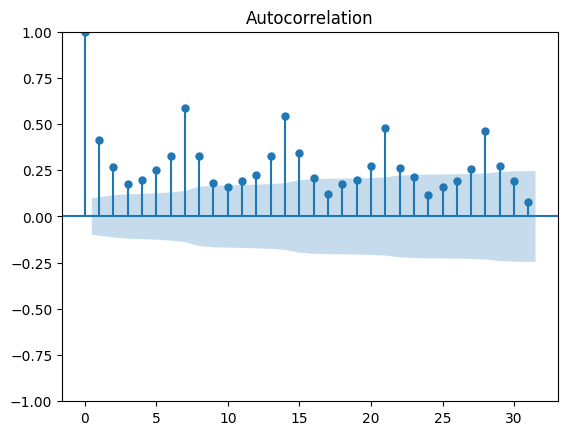

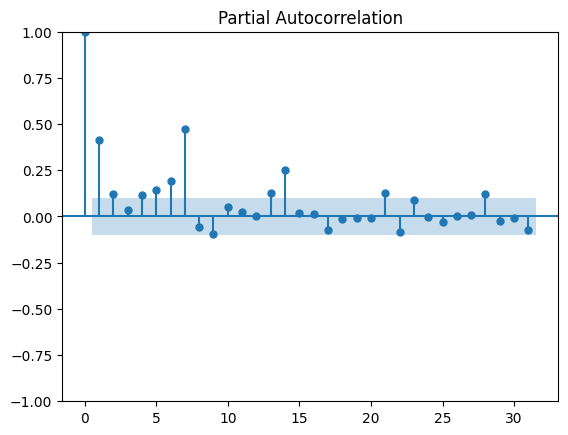

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf
import statsmodels.tsa.api as tsa
plt.figure(figsize=(10, 4))
# lags=30 で過去30日分までの相関を確認
plot_acf(df_pfood['sales'], lags=31)
tsa.acf(df_pfood['sales'], nlags=31)
plot_pacf(df_pfood['sales'], lags=31)
tsa.pacf(df_pfood['sales'], nlags=31)

### モデルにインプットさせる説明変数の選択
コレログラムの結果から、売り上げ量は1日前,7日前,14日前,21日前,28日前との値と相関が比較的強いと捉え、これらの値を説明変数に追加する。(lag_1～lag_28)、またトレンドの影響を考慮させるために7日間移動平均と28日間移動平均の値も追加。

In [ ]:


def create_features(df1):
    # 元データを書き換えないようにコピー
    df1 = df_pfood.copy()

    # 1. is_event が 1 の日の is_workday を 0（休日扱い）にする
    if 'is_event' in df1.columns:
        df1.loc[df1['is_event'] == 1, 'is_workday'] = 0

        # 処理が終わったので is_event 列を削除
        df1 = df1.drop(columns=['is_event'])

    # 2. 'month'（月: 1〜12）をインデックス（date）から抽出して追加
    df1['month'] = df1.index.month

    # 3. ラグ特徴量（1, 7, 14, 21, 28日前）の作成
    # ※カテゴリ(family)ごとに計算しないと、別の商品の売上を持ってきてしまうので注意
    lags =[1, 7, 14, 21, 28]
    for lag in lags:
        df1[f'lag_{lag}'] = df1['sales'].shift(lag)

    # 4. 移動平均（7日間、28日間）の作成
    # ※予測に「今日」の売上は使えないので、shift(1)で「昨日までの」データにするのが絶対条件
    rolls = [7, 28]
    for roll in rolls:
        df1[f'roll_{roll}'] = df1['sales'].transform(
            lambda x: x.shift(1).rolling(window=roll).mean()
        )

    return df1

# 特徴量作成関数の実行
df_featured = create_features(df_f)

# 確認：dropnaする前のデータ件数
print(f"dropna前のデータ件数: {len(df_featured)}件")

# 5. NaNを含む行（最初の約28日間）を削除
df_featured = df_featured.dropna()

# 確認：dropnaした後のデータ件数
print(f"dropna後のデータ件数: {len(df_featured)}件")

# データの先頭部分を確認（日付が 2016-08-15 からではなく、28日後から始まっているはずです）
display(df_featured.head(10))
display(df_featured.tail(10))

dropna前のデータ件数: 396件
dropna後のデータ件数: 368件


,sales,onpromotion,is_workday,day_of_week,oil_price,month,lag_1,lag_7,lag_14,lag_21,lag_28,roll_7,roll_28
date,,,,,,,,,,,,,
2016-08-12,399.02100,1,0,4,44.47,8,322.57000,391.98800,378.66998,443.34500,390.693,344.343571,355.546750
2016-08-13,319.23700,0,0,5,44.47,8,399.02100,363.38100,327.82300,322.59200,384.655,345.348286,355.844179
2016-08-14,324.44202,0,0,6,44.47,8,319.23700,346.77500,385.45300,392.83100,423.589,339.042000,353.507821
2016-08-15,308.48300,0,0,0,45.72,8,324.44202,337.69300,372.52200,314.43200,437.400,335.851574,349.966858
2016-08-16,350.00900,0,1,1,46.57,8,308.48300,275.60100,362.05100,293.75600,347.349,331.678717,345.362679
2016-08-17,351.25300,1,1,2,46.81,8,350.00900,372.39700,351.76500,319.09600,427.958,342.308431,345.457679
2016-08-18,227.54100,0,1,3,48.20,8,351.25300,322.57000,306.65400,264.80402,297.466,339.287860,342.718215
2016-08-19,338.74402,1,1,4,48.48,8,227.54100,399.02100,391.98800,378.66998,443.345,325.712289,340.220894
2016-08-20,418.03900,0,0,5,48.48,8,338.74402,319.23700,363.38100,327.82300,322.592,317.101291,336.485144


,sales,onpromotion,is_workday,day_of_week,oil_price,month,lag_1,lag_7,lag_14,lag_21,lag_28,roll_7,roll_28
date,,,,,,,,,,,,,
2017-08-06,327.892,0,0,6,49.57,8,275.778,314.66700,316.145,258.366,285.499,242.089141,253.825321
2017-08-07,214.556,0,1,0,49.37,8,327.892,193.79500,286.961,212.156,218.948,243.978427,255.339357
2017-08-08,193.132,0,1,1,49.07,8,214.556,266.68800,261.268,221.982,254.642,246.944284,255.182500
2017-08-09,255.534,0,1,2,49.59,8,193.132,210.95999,203.463,217.573,195.954,236.436284,252.985714
2017-08-10,197.133,0,1,3,48.54,8,255.534,183.06300,271.172,287.049,230.951,242.804000,255.113571
2017-08-11,288.315,0,0,4,48.81,8,197.133,249.67300,228.299,273.543,263.639,244.814000,253.905785
2017-08-12,231.714,0,0,5,48.81,8,288.315,275.77800,290.234,336.667,297.974,250.334286,254.787071
2017-08-13,198.679,0,0,6,48.81,8,231.714,327.89200,314.667,316.145,258.366,244.039429,252.420643
2017-08-14,215.657,0,1,0,47.59,8,198.679,214.55600,193.795,286.961,212.156,225.580429,250.288964


### lightGBMでモデルを作成し、2017-08-01～2017-08-15の売り上げ量を予測
先程のデータの内2016-08-12～2017-07-31のデータを学習させてモデルを作成
→2017-08-01～2017-08-15の売り上げ量を予測し、グラフで可視化

注：このグラフは、AIが毎日『明日の売上』を日々ローリング予測した結果をプロットしたものである。すなわち15日先を一気に予測したものではない。
現場の業務に合わせて、『8月1日の夕方に、明日の分を予測する』『8月2日の夕方に、明日の分を予測する』という、日々の1日先予測（1-step ahead forecasting）を15日間繰り返した結果を繋ぎ合わせたものを示す。

Train件数: 323, Valid件数: 30, Test件数: 15
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[510]	training's rmse: 0.323402	valid_1's rmse: 0.119399


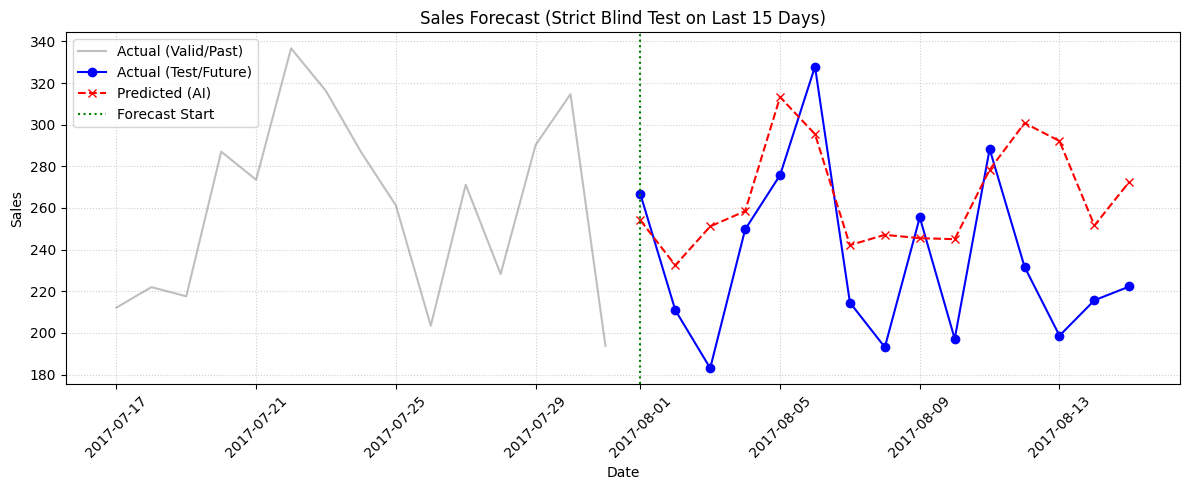

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import lightgbm as lgb

# --- 特徴量作成（名前の不一致を修正） ---
def create_features_improved(df_input):
    df1 = df_input.copy()

    if 'is_event' in df1.columns:
        df1.loc[df1['is_event'] == 1, 'is_workday'] = 0
        df1 = df1.drop(columns=['is_event'])

    df1['month'] = df1.index.month
    df1['day_of_week'] = df1.index.dayofweek
    df1['is_weekend'] = df1['day_of_week'].isin([5, 6]).astype(int)
    df1['promo_weekend'] = df1['onpromotion'] * df1['is_weekend']

    lags = [1, 7, 14, 21, 28]
    for lag in lags:
        df1[f'lag_{lag}'] = df1['sales'].shift(lag)

    rolls = [7, 28]
    for roll in rolls:
        df1[f'roll_{roll}'] = df1['sales'].transform(
            lambda x: x.shift(1).rolling(window=roll).mean()
        )

    # ★ここを 'diff_1_7' から 'diff_ratio' に変更（リスト側に合わせます）
    df1['diff_ratio'] = df1['lag_1'] / (df1['lag_7'] + 1e-6)

    return df1

# 特徴量作成の実行
# ※ filtered_df(元データ) から作成するようにしてください
df_featured = create_features_improved(df_pfood) # df_f などの元データ変数を指定
df_featured = df_featured.dropna()

# --- データの分割 ---
test_days = 15
valid_days = 30
test_start_idx = len(df_featured) - test_days
valid_start_idx = test_start_idx - valid_days

train = df_featured.iloc[:valid_start_idx]
valid = df_featured.iloc[valid_start_idx:test_start_idx]
test = df_featured.iloc[test_start_idx:]

print(f"Train件数: {len(train)}, Valid件数: {len(valid)}, Test件数: {len(test)}")

# --- 学習用データの準備（対数変換を反映） ---
features = [
    'onpromotion', 'is_workday', 'month', 'day_of_week', 'is_weekend',
    'promo_weekend', 'oil_price', 'lag_1', 'lag_7', 'lag_14', 'lag_21',
    'lag_28', 'roll_7', 'roll_28', 'diff_ratio'
]
cat_features = ['month', 'day_of_week', 'is_workday', 'is_weekend', 'onpromotion', 'promo_weekend']

# ★重要：売上を対数変換(log1p)したものを目的変数(y)にする
X_train, y_train = train[features], np.log1p(train['sales'])
X_valid, y_valid = valid[features], np.log1p(valid['sales'])
X_test, y_test = test[features], np.log1p(test['sales'])

# --- LightGBMの学習 ---
params = {
    'objective': 'regression',
    'metric': 'rmse',
    'boosting_type': 'gbdt',
    'random_state': 42,
    'learning_rate': 0.01,
    'num_leaves': 10,
    'max_depth': 3,
    'min_child_samples': 10,
    'colsample_bytree': 0.8,
    'subsample': 0.8,
    'verbosity': -1,
    'lambda_l1': 0.5,             # Ｌ1正則化。不要な特徴量の影響をゼロに近づける。
    'lambda_l2': 1.0,             # L2正則化。予測値が極端に大きくなるのを防ぐ。

    # --- 修正ポイント4：データのバラつきに対応する ---
    'min_child_samples': 20,      # 1つの分岐に最低20サンプル必要。
    'feature_fraction': 0.7,      # 毎回使う特徴量を70%に絞り、特定の変数（lag_1等）への依存を減らす。
    'bagging_fraction': 0.7,      # データの70%をランダムに使う。
    'bagging_freq': 5,
}

model = lgb.LGBMRegressor(**params, n_estimators=2000)
model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_valid, y_valid)],
    categorical_feature=cat_features,
    callbacks=[lgb.early_stopping(stopping_rounds=50)]
)

# --- 予測と逆変換 ---
y_pred_log = model.predict(X_test)
# 対数変換を元に戻す(expm1)
y_pred = np.expm1(y_pred_log)
y_actual = np.expm1(y_test)
y_valid_actual = np.expm1(y_valid)

# 結果の格納
test_result = test.copy()
test_result['predicted_sales'] = y_pred

# --- グラフ表示 ---
plt.figure(figsize=(12, 5))
plt.plot(valid.index[-15:], y_valid_actual.iloc[-15:], label='Actual (Valid/Past)', color='gray', alpha=0.5)
plt.plot(test_result.index, test_result['sales'], label='Actual (Test/Future)', color='blue', marker='o')
plt.plot(test_result.index, test_result['predicted_sales'], label='Predicted (AI)', color='red', linestyle='--', marker='x')
plt.axvline(x=test.index[0], color='green', linestyle=':', label='Forecast Start')
plt.title('Sales Forecast (Strict Blind Test on Last 15 Days)')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.xticks(rotation=45)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

=== 特徴量重要度ランキング（AIが予測で重視した項目） ===


,Feature,Importance (Gain)
8,lag_7,223.518383
13,roll_28,110.665662
12,roll_7,108.340075
9,lag_14,68.384452
6,oil_price,67.340417
14,diff_ratio,57.463844
11,lag_28,50.531122
10,lag_21,44.623016
1,is_workday,40.535528
7,lag_1,37.847182


/tmp/ipykernel_7044/4082830252.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance (Gain)', y='Feature', data=importance_df.head(15), palette='viridis')


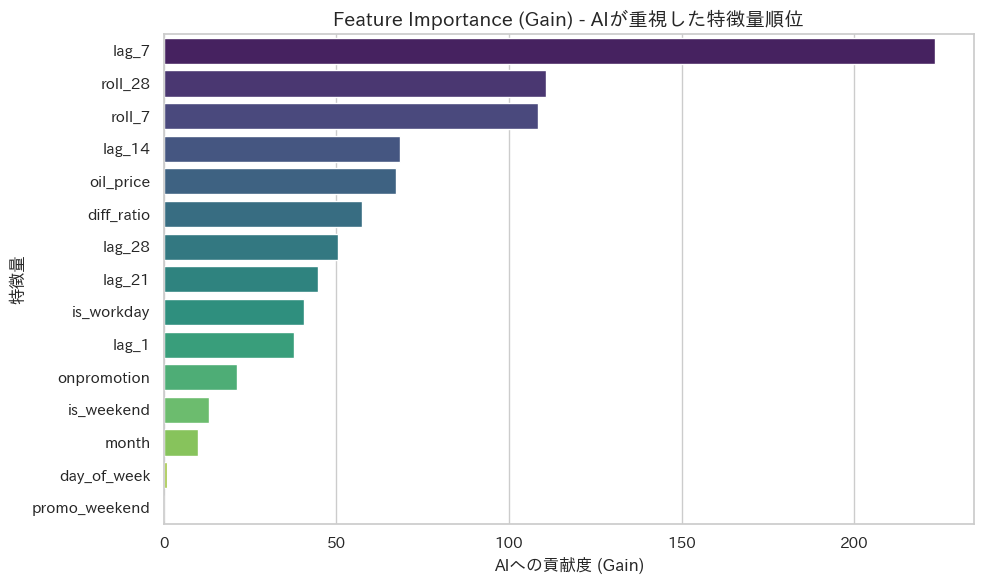

In [ ]:
!pip install japanize-matplotlib -q
import japanize_matplotlib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. モデルの内部(booster)から、'gain'（売上予測への貢献度）ベースの重要度を取得
# （LGBMRegressorの場合は .booster_ を挟むと確実に取り出せます）
importances = model.booster_.feature_importance(importance_type="gain")

# 2. 特徴量の名前を取得
feature_names = X_train.columns

# 3. 見やすいようにPandasのデータフレームにして、重要度が高い順に並び替え
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance (Gain)': importances
}).sort_values(by='Importance (Gain)', ascending=False)

# 表として出力（上位10個）
print("=== 特徴量重要度ランキング（AIが予測で重視した項目） ===")
display(importance_df.head(15))

# 4. 商談用に綺麗な棒グラフにする
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance (Gain)', y='Feature', data=importance_df.head(15), palette='viridis')
plt.title('Feature Importance (Gain) - AIが重視した特徴量順位', fontsize=14, fontweight='bold')
plt.xlabel('AIへの貢献度 (Gain)', fontsize=12)
plt.ylabel('特徴量', fontsize=12)
plt.tight_layout()
plt.show()

### 様々な評価指標での予測値の評価

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
import numpy as np

# 1. 実際の値と予測値を取得
y_true = test_result['sales']
y_pred = test_result['predicted_sales']

# 2. 各指標の算出
mae = mean_absolute_error(y_true, y_pred)           # 平均絶対誤差
mse = mean_squared_error(y_true, y_pred)            # 平均二乗誤差
rmse = np.sqrt(mse)                                 # RMSE（二乗を元に戻したもの）
mape = mean_absolute_percentage_error(y_true, y_pred) # 平均絶対誤差率

# MASE算出用関数
def calculate_mase(y_true, y_pred, y_train, seasonality=7):
    mae_test = mean_absolute_error(y_true, y_pred)
    naive_diff = np.abs(y_train.values[seasonality:] - y_train.values[:-seasonality])
    mae_naive = np.mean(naive_diff)
    return mae_test / mae_naive

mase = calculate_mase(y_true, y_pred, train['sales'], seasonality=7)

# 結果の表示
print(f"--- 予測精度評価結果 ---")
print(f"MAE  (平均絶対誤差): {mae:.2f}")
print(f"RMSE (二乗平均平方根誤差): {rmse:.2f}")
print(f"MAPE (平均絶対誤差率): {mape:.2%}")
print(f"MASE (平均絶対スケーリング誤差): {mase:.4f}")

# ビジネス的な解釈の補助（売上の平均に対する誤差の割合）
avg_sales = y_true.mean()
error_ratio = mae / avg_sales
print(f"\n【ビジネス解釈】")
print(f"テスト期間の平均売上: {avg_sales:.2f}")
print(f"平均的なズレ（個数/金額）: ±{mae:.2f}")
print(f"売上に対する誤差の比率: {error_ratio:.2%}")

--- 予測精度評価結果 ---
MAE  (平均絶対誤差): 38.61
RMSE (二乗平均平方根誤差): 45.67
MAPE (平均絶対誤差率): 17.85%
MASE (平均絶対スケーリング誤差): 0.6352

【ビジネス解釈】
テスト期間の平均売上: 235.40
平均的なズレ（個数/金額）: ±38.61
売上に対する誤差の比率: 16.40%


### 指標の説明

MAE・・・誤差の絶対値の平均。「平均してどれくらい外れているか」がそのまま分かるので、直感的で分かりやすい。外れ値の影響は比較的小さめ。

RMSE・・・誤差を二乗して平均し、その平方根を取ったもの。大きな誤差を二乗で強く罰するので、大きく外れた予測を特に重く見るときに向いていまる。単位は元のデータと同じ。

MAPE・・・誤差を実測値で割って％にした平均。「何％ずれたか」が分かるので、異なるスケールのデータ同士でも比較可能。

MASE・・・自分のモデルの MAE を、単純な持続予測の誤差で割ったもの。1より小さければ、先週の値をそのまま予測値として使う場合より良いと解釈できる。


### 一言で

MAE：平均でどれだけ外れたか。

RMSE：大きく外れたミスを重く評価する。

MAPE：どれだけ％ずれたか。

MASE：単純予測と比べてどれだけ良いか

# 総評

評価指標の内、「MAPE（平均絶対誤差率）」は非技術者に説明しやすい代表的な指標の一つである。ただし、小売実務では WMAPE や MASE、予測バイアスも併せて確認する必要がある。、一般的な基準（小売業の日次売上予測の場合）としては、

10% 未満：神業レベル（天候に左右されない安定した商材でないと不可能に近い）
10% 〜 20%：実用レベル（優秀）。人間の発注業務のベースラインとして十分に使える。
20% 〜 30%：参考値レベル。AIの数値をそのまま鵜呑みにできず、人間の修正が多く必要。
30% 以上：使い物にならない。
とされている。

本モデルによる予測値のMAPEを見てみると、17.85%となっており、スーパーの日次予測としては、人間による発注作業のベース（下書き）として十分信頼できる精度であるといえる。
また、MASE=0.63 は、採用した『先週踏襲型の予測』を基準にすると、本モデルの平均絶対誤差が約37%小さいことを示す。
これは現場の経験則ベースの予測より改善余地があることを示唆するが、欠品率や廃棄率の改善幅は発注ルールや在庫制約に依存するため、別途PoCで検証が必要である。
さらに、予測期間の平均売り上げ量235.4に対して、MAEの値から、予測値は平均して±38.61の値を予測することから、直感的ではあるが充分な精度を持つと言えるのではないだろうか(38.61/235.4≒16.40%)。

しかし、予測値のグラフと実測値のグラフを重ね合わた結果をよく見てみると、

① 予測値が実測値ほど下がりきっていない箇所が所々見られる
② 8/12以降の予測が大きく外れている

という事実があり、これら2つの問題を解決することでさらに精度を上げることができることが分かる。

**①の要因分析**

・AIが「安全側（平均）」に逃げている（正則化の影響）・・・

パラメータ調整で、過学習を防ぐために「L2正則化」などを強めた。これにより、AIは「極端な外れ値（異常な高値や安値）を予測して大失敗する」ことを恐れるようになり、結果として予測値が全体的に「無難な平均値」に寄りやすく（平滑化されやすく）なっていることが考えられる。

・「売上が下がる理由」のデータが入っていない・・・

特売日や週末など「売上が上がる要因」はデータに入っているが、「悪天候」「近隣ライバル店の特売」「近くでのイベントによる客離れ」「在庫の欠品」といった、売上を大きくと落とすマイナス要因のデータがAIに与えられていない。そのため、AIはこのような日の予測値を、実際よりも高めに予測してしまうと考えられる。

**②の要因分析**

グラフを見ると、8/12〜8/15にかけて実測値（青）は低迷しているのに、予測値（赤）は上に大きく外している。これには時系列特有の罠と今回の分析対象であるスーパーが所在するエクアドルのカレンダー事情が絡んでいると考えられる。

・給料日前（15日）の「買い控え」を学習できていない・・・

このデータセットの舞台である南米（エクアドル）では、給料日は「月末」と「15日」の月2回が一般的。
つまり、8/12〜14は「給料日直前で、一番出費が抑えられる時期」である。しかし、現在のAIには「給料日フラグ」が入っていないため、この買い控え現象を予測できず、高く見積もってしまった。

・テストデータ期間の売り上げ量の異常推移の要因特定が出来ていない・・・

2017の8/6〜8/15の実測値は、8/6と8/11を除いてほぼ全てが「230以下」という、年間ワースト25%をさらに下回る異常な低水準で推移している。本オープンデータで店舗のドメイン情報や在庫情報などは取得できなかったため、このイレギュラーな低水準推移の要因が不明で説明変数に入れられていない。そのため、『普段の水準』に引っ張られて高く予測してしまったと考えられる。



このAIは純粋な過去の数字（先週の売上など）と最低限の外生変数だけでここまで波形を当てている。本番導入時に、『給料日サイクル』『ポイント倍増日』『近隣のイベント』『地域情報』『在庫情報』『プロモーション期間』といった現場のノウハウを追加の変数としてAIに組み込むことで、この『下がりきらない谷』や『見当違いの跳ね上がり』を実測値により合わせることが可能になる。
つまり、このAIは現場の知見を足せば足すほど、上記の評価値をボトムとしてさらに精度を高めることが可能なシステムである。



### 目的変数と説明変数一覧

In [ ]:
df_featured.head(10)

,sales,onpromotion,is_workday,day_of_week,oil_price,month,is_weekend,promo_weekend,lag_1,lag_7,lag_14,lag_21,lag_28,roll_7,roll_28,diff_ratio
date,,,,,,,,,,,,,,,,
2016-08-12,399.02100,1,0,4,44.47,8,0,0,322.57000,391.98800,378.66998,443.34500,390.693,344.343571,355.546750,0.822908
2016-08-13,319.23700,0,0,5,44.47,8,1,0,399.02100,363.38100,327.82300,322.59200,384.655,345.348286,355.844179,1.098079
2016-08-14,324.44202,0,0,6,44.47,8,1,0,319.23700,346.77500,385.45300,392.83100,423.589,339.042000,353.507821,0.920588
2016-08-15,308.48300,0,0,0,45.72,8,0,0,324.44202,337.69300,372.52200,314.43200,437.400,335.851574,349.966858,0.960760
2016-08-16,350.00900,0,1,1,46.57,8,0,0,308.48300,275.60100,362.05100,293.75600,347.349,331.678717,345.362679,1.119310
2016-08-17,351.25300,1,1,2,46.81,8,0,0,350.00900,372.39700,351.76500,319.09600,427.958,342.308431,345.457679,0.939881
2016-08-18,227.54100,0,1,3,48.20,8,0,0,351.25300,322.57000,306.65400,264.80402,297.466,339.287860,342.718215,1.088920
2016-08-19,338.74402,1,1,4,48.48,8,0,0,227.54100,399.02100,391.98800,378.66998,443.345,325.712289,340.220894,0.570248
2016-08-20,418.03900,0,0,5,48.48,8,1,0,338.74402,319.23700,363.38100,327.82300,322.592,317.101291,336.485144,1.061105


### 惣菜の売り上げ量の推移と統計解析

,sales
count,368.000000
mean,340.734256
std,90.785199
min,0.000000
25%,280.024245
50%,331.735500
75%,399.885250
max,666.917970


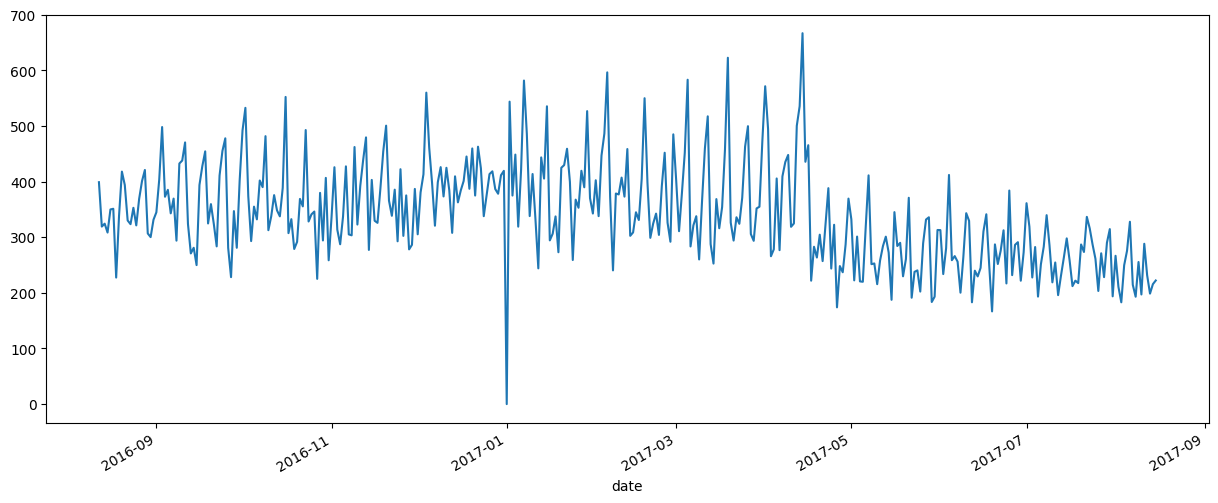

In [ ]:
df_featured['sales'].plot(figsize=(15, 6))
df_featured['sales'].describe()

In [ ]:
import plotly.express as px

fig = px.line(df_featured, x=df_featured.index, y='sales', title='売上数量の推移 (Plotly版)')
fig.show()

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 41.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


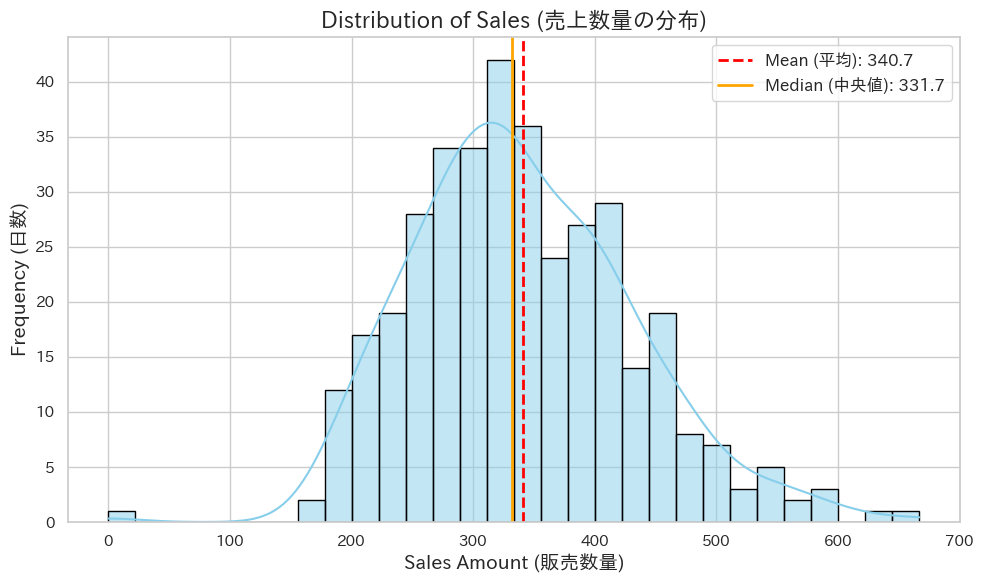

In [ ]:
# 1. 日本語対応フォントのインストール
!pip install japanize-matplotlib -q

import matplotlib.pyplot as plt
import seaborn as sns
import japanize_matplotlib  # 2. インストールしたフォントを読み込む

# グラフのスタイル設定
sns.set_theme(style="whitegrid")
# seabornのスタイルを設定するとフォントがリセットされることがあるため、再度日本語フォントを指定
plt.rcParams['font.family'] = 'IPAexGothic'

plt.figure(figsize=(10, 6))

# ヒストグラムの描画
sns.histplot(df_featured['sales'], bins=30, kde=True, color='skyblue', edgecolor='black')

# 平均値と中央値を計算して垂直線を引く
mean_val = df_featured['sales'].mean()
median_val = df_featured['sales'].median()

plt.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean (平均): {mean_val:.1f}')
plt.axvline(median_val, color='orange', linestyle='-', linewidth=2, label=f'Median (中央値): {median_val:.1f}')

# タイトルと軸ラベルの設定（今度は綺麗に日本語が表示されます！）
plt.title('Distribution of Sales (売上数量の分布)', fontsize=16, fontweight='bold')
plt.xlabel('Sales Amount (販売数量)', fontsize=14)
plt.ylabel('Frequency (日数)', fontsize=14)
plt.legend(fontsize=12)

# レイアウトを整えて表示
plt.tight_layout()
plt.show()